In [280]:
import os

for root, dirs, files in os.walk('/'):
    for file in files:
        if file.endswith('.xlsx'):
            print(os.path.join(root, file))

/01 Retail Inventory.xlsx
/usr/lib/R/site-library/readxl/extdata/type-me.xlsx
/usr/lib/R/site-library/readxl/extdata/deaths.xlsx
/usr/lib/R/site-library/readxl/extdata/clippy.xlsx
/usr/lib/R/site-library/readxl/extdata/datasets.xlsx
/usr/lib/R/site-library/readxl/extdata/geometry.xlsx


In [281]:
import pandas as pd

df = pd.read_excel('/01 Retail Inventory.xlsx')

df.head()

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
0,PRD-1001,Wine Glasses,Home & Kitchen,Heritage Brands,23.78,38.89,135,118,17,30,Low Stock
1,PRD-1002,Eye Mask,Beauty,Coastal Trading,15.67,24.53,86,10,76,9,In Stock
2,PRD-1003,Resistance Band,Sports & Outdoors,National Supply Group,5.59,11.88,319,195,124,47,In Stock
3,PRD-1004,Action Figure,Toys & Games,Pacific Wholesale,9.72,18.01,173,140,33,39,Low Stock
4,PRD-1005,Serving Tray,Home & Kitchen,Coastal Trading,8.22,13.90,32,8,24,7,In Stock


In [282]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product ID     1000 non-null   object 
 1   Product Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Supplier Name  1000 non-null   object 
 4   Unit Cost      1000 non-null   float64
 5   Retail Price   1000 non-null   float64
 6   Opening Stock  1000 non-null   int64  
 7   Units Sold     1000 non-null   int64  
 8   Closing Stock  1000 non-null   int64  
 9   Reorder Point  1000 non-null   int64  
 10  Stock Status   1000 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


In [283]:
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier Name,0
Unit Cost,0
Retail Price,0
Opening Stock,0
Units Sold,0
Closing Stock,0
Reorder Point,0


In [284]:
df.duplicated().sum()

np.int64(0)

In [285]:
df.describe()

,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,16.061210,27.976780,262.451000,137.040000,125.411000,44.98300
std,14.172094,24.915064,140.104457,103.623232,99.023521,27.54468
min,0.520000,1.070000,20.000000,3.000000,4.000000,2.00000
25%,7.035000,11.962500,141.750000,53.000000,44.000000,22.00000
50%,12.430000,21.760000,261.000000,108.500000,96.000000,41.00000
75%,20.775000,35.307500,388.000000,204.000000,190.000000,64.25000
max,78.790000,157.400000,499.000000,463.000000,432.000000,119.00000


In [286]:
# Remove duplicates if any
df = df.drop_duplicates()

# Check again
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [287]:
category_count = df['Category'].value_counts()
print(category_count)

Category
Beauty               134
Sports & Outdoors    132
Electronics          126
Office Supplies      126
Home & Kitchen       124
Toys & Games         123
Grocery              119
Clothing             116
Name: count, dtype: int64


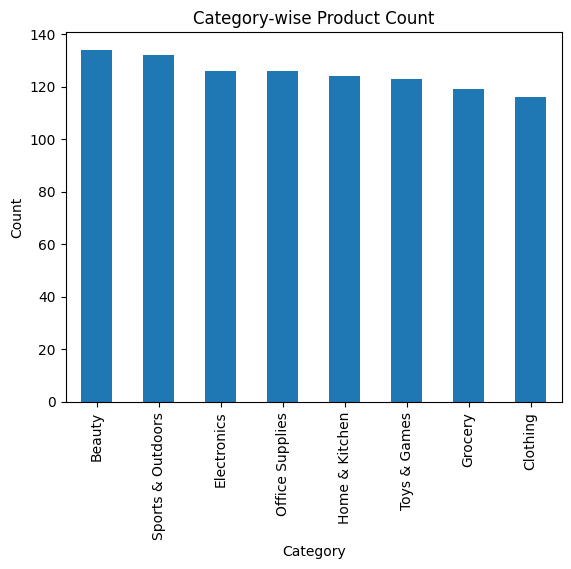

In [288]:
import matplotlib.pyplot as plt

category_count.plot(kind='bar')
plt.title("Category-wise Product Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [289]:
category_sales = df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False)

print(category_sales)

Category
Toys & Games         19704
Home & Kitchen       18387
Beauty               18137
Electronics          17621
Office Supplies      17112
Sports & Outdoors    16979
Grocery              15364
Clothing             13736
Name: Units Sold, dtype: int64


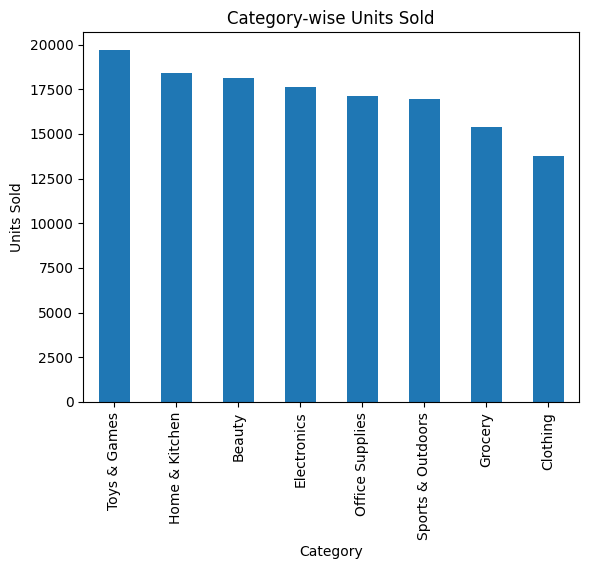

In [290]:
category_sales.plot(kind='bar')
plt.title("Category-wise Units Sold")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.show()

In [291]:
top10 = df.sort_values('Units Sold', ascending=False).head(10)

top10[['Product Name','Units Sold']]

,Product Name,Units Sold
721,Water Bottle,463
476,Canned Soup,456
791,Coffee Mug Set,435
673,LED Desk Lamp,432
810,Coloring Set,428
243,Notebook A5,423
970,Baseball Cap,422
550,Whistle,422
931,Rice Crackers,417
469,Building Blocks,416


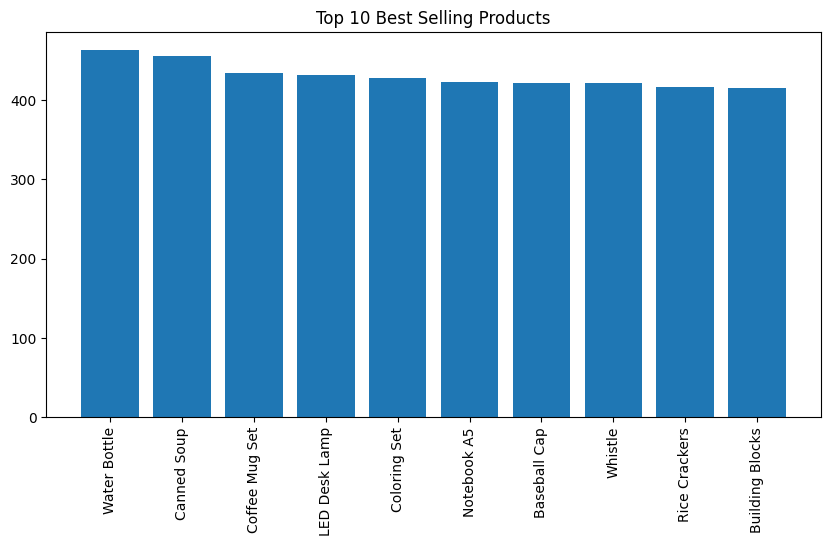

In [292]:
plt.figure(figsize=(10,5))

plt.bar(top10['Product Name'], top10['Units Sold'])

plt.xticks(rotation=90)
plt.title("Top 10 Best Selling Products")

plt.show()

In [293]:
low_stock = df.sort_values('Closing Stock').head(10)

low_stock[['Product Name','Closing Stock']]

,Product Name,Closing Stock
45,Basic T-Shirt,4
385,Coloring Set,4
819,Notebook A5,4
654,Storage Container,4
425,Nail File Set,5
391,Eye Mask,5
703,Coffee Mug Set,5
977,Cotton Pads,6
698,Whistle,6
709,Dry Shampoo,6


In [294]:
supplier_count = df['Supplier Name'].value_counts()

print(supplier_count)

Supplier Name
Premier Merchandise      119
National Supply Group    116
Heritage Brands          109
Coastal Trading          103
Global Source Direct     103
United Imports            99
Pacific Wholesale         98
Summit Wholesale Inc      92
Metro Distributors        89
AllGoods Supply Co        72
Name: count, dtype: int64


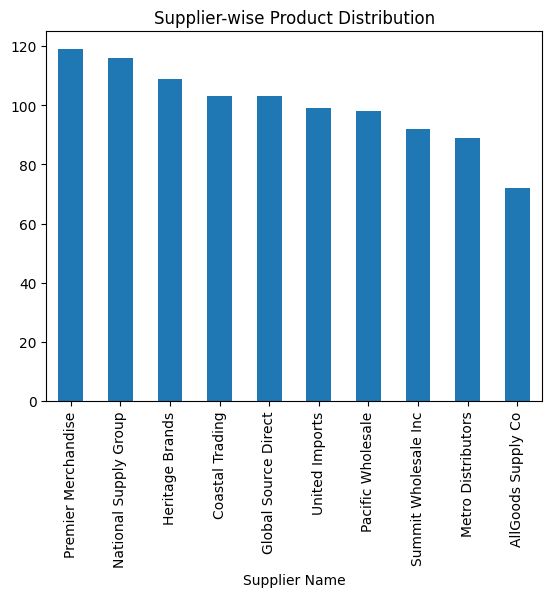

In [295]:
supplier_count.plot(kind='bar')

plt.title("Supplier-wise Product Distribution")

plt.show()

In [296]:
df['Profit'] = (df['Retail Price'] - df['Unit Cost']) * df['Units Sold']

df[['Product Name','Profit']].head()

,Product Name,Profit
0,Wine Glasses,1782.98
1,Eye Mask,88.60
2,Resistance Band,1226.55
3,Action Figure,1160.60
4,Serving Tray,45.44


In [297]:
df.sort_values('Profit', ascending=False)[['Product Name','Profit']].head(10)

,Product Name,Profit
673,LED Desk Lamp,28697.76
792,Screen Protector,20771.64
334,Power Bank,15789.55
339,USB Cable,15262.17
87,Smart Plug,14490.04
525,Power Bank,14056.17
173,Phone Case,13530.08
952,Phone Case,13026.42
120,Wireless Earbuds,13020.57
329,Basic T-Shirt,12560.16


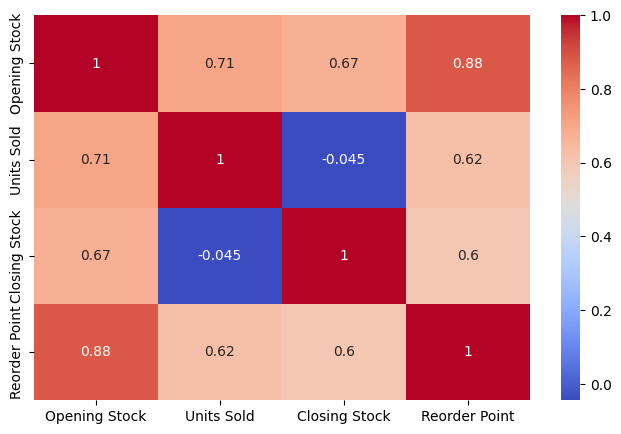

In [298]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Opening Stock','Units Sold','Closing Stock','Reorder Point']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

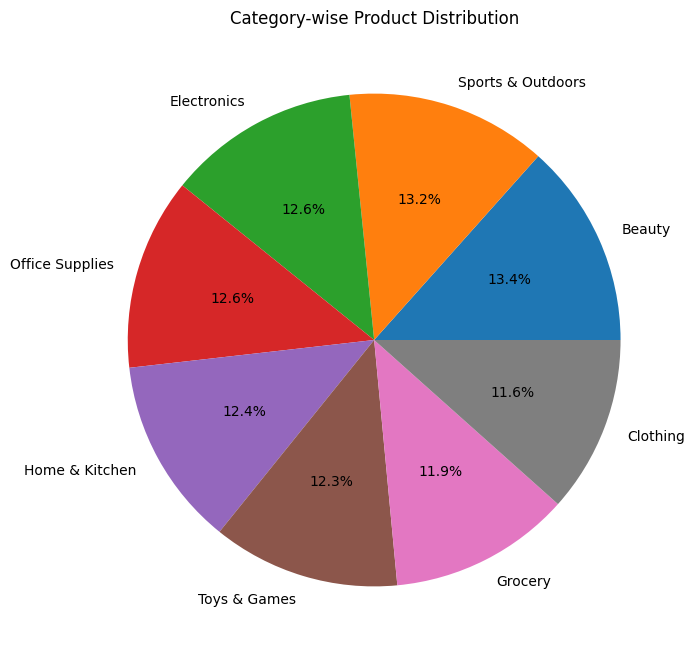

In [299]:
category_count = df['Category'].value_counts()

category_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Category-wise Product Distribution')
plt.ylabel('')
plt.show()

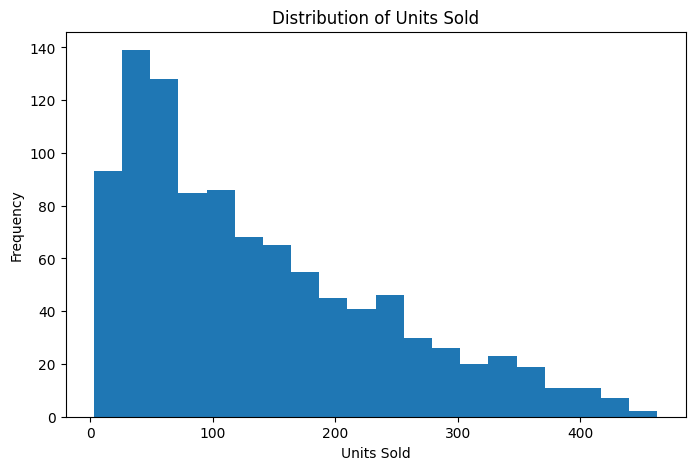

In [300]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Units Sold'],
    bins=20
)

plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

plt.show()

In [301]:
top10 = df.sort_values(
    by='Units Sold',
    ascending=False
).head(10)

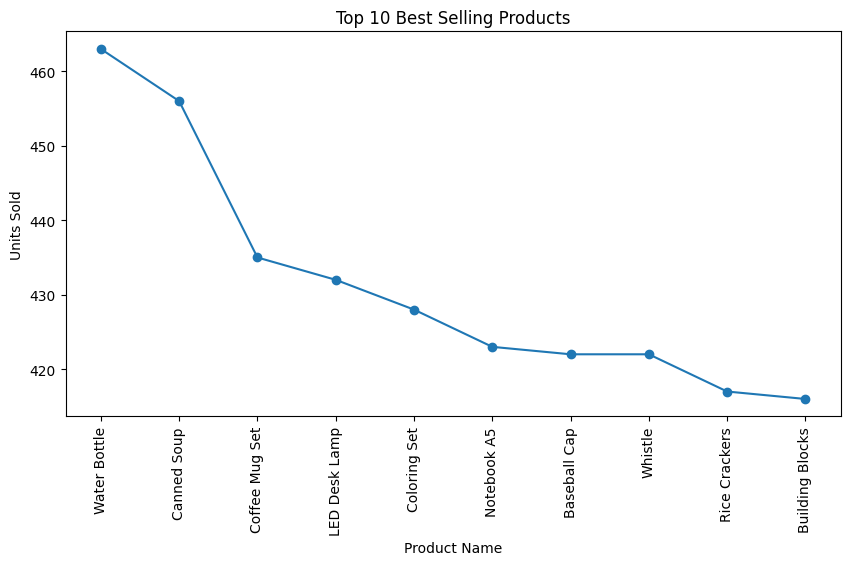

In [302]:
plt.figure(figsize=(10,5))

plt.plot(
    top10['Product Name'],
    top10['Units Sold'],
    marker='o'
)

plt.xticks(rotation=90)

plt.title('Top 10 Best Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Units Sold')

plt.show()